# PCOS Symptoms: Medical Records vs. Patient Voices

This notebook provides an interactive visualization of the project results.

It calls functions from the `src/` modules to:
- load and preprocess the clinical dataset
- collect and analyze Reddit symptom discussions
- compare patterns between the clinical data and Reddit posts
- display classifer importance results
- display lifestyle factors 

The notebook does not contain the main implementation logic. It is used to run the project pipeline and display the results.

In [19]:
# AI generated: portions of this file were created with assistance of ChatGPT

from kaggle_pcosdata import load_pcos_data, calculate_symptom_percentages, plot_symptom_prevalence
from reddit_api import fetch_reddit_posts, count_reddit_symptoms, plot_reddit_symptoms
from PCOS_source_comparison import compare_symptoms

from medical_logisticregression import run_medical_logistic_regression
from medical_svm import run_medical_svm
from medical_randomforest import run_medical_random_forest

from lifestyle_analysis import run_lifestyle_analysis

from IPython.display import Image, display
import matplotlib.pyplot as plt

## Medical Symptom Analysis

This section loads the clinical PCOS dataset and calculates observable symptom prevalence among diagnosed PCOS patients.

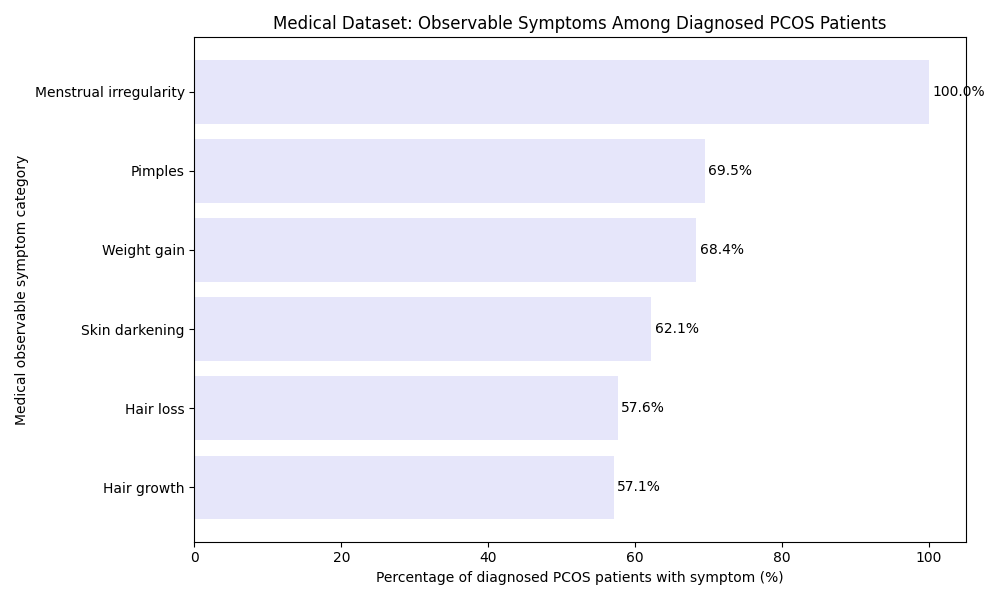

In [37]:
plot_symptom_prevalence(medical_result)
display(Image(filename="results/pcos_symptom_prevalence.png"))

## Reddit Symptom Analysis

This section collects r/PCOS posts and counts how often observable symptom categories appear in Reddit discussions.

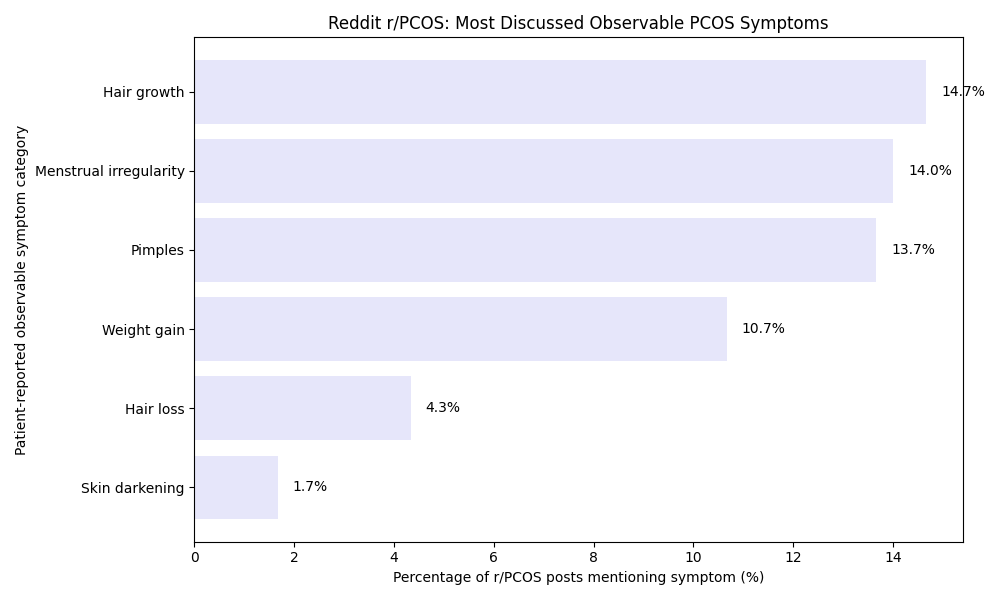

In [34]:
plot_reddit_symptoms(reddit_result)
display(Image(filename="results/reddit_symptom_prevalence.png"))

## Medical Dataset vs Reddit Comparison

This section compares symptom prevalence in the medical dataset with symptom discussion frequency in Reddit posts.

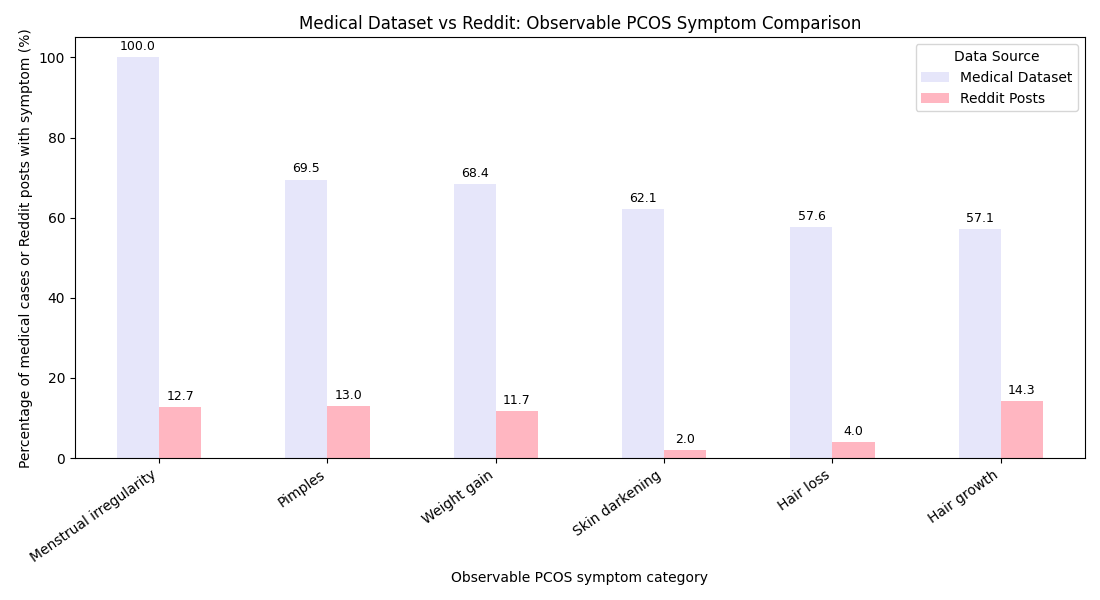

In [39]:
display(Image(filename="results/comparison_chart.png"))

## Logistic Regression Model

This section displays the Logistic Regression model results for predicting PCOS diagnosis using observable symptoms.


Logistic Regression Model Performance:
Accuracy: 0.87
Error: 0.13
Precision: 0.82
Recall: 0.78
F1-score: 0.80

Logistic Regression Coefficients:
              Symptom  Coefficient
1        Cycle length    -0.232705
5           Hair loss     0.119723
0  Cycle irregularity     0.526044
6             Pimples     0.759315
2         Weight gain     1.080408
3         Hair growth     1.409080
4      Skin darkening     1.446388


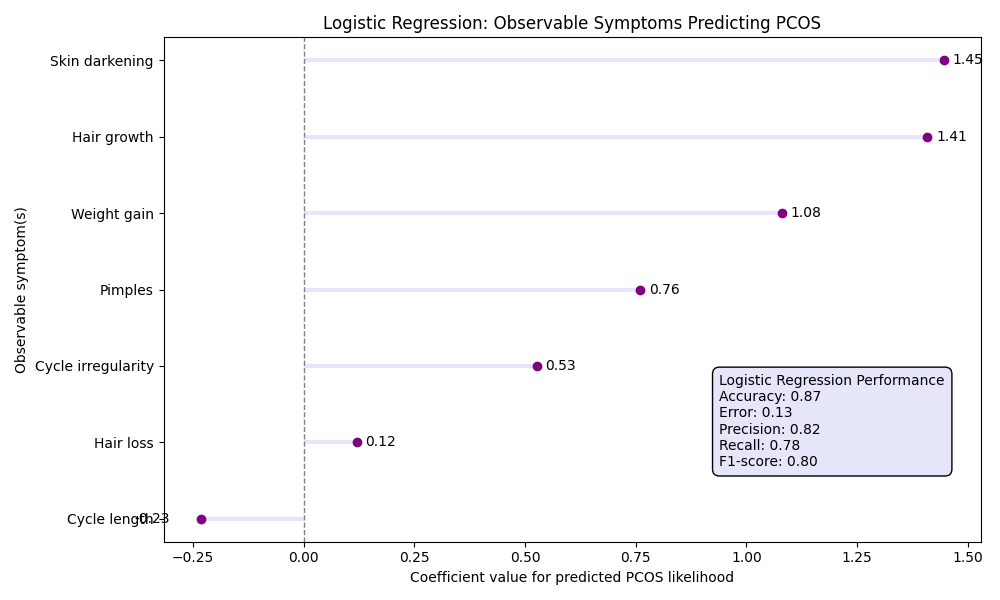

In [41]:
logistic_result = run_medical_logistic_regression()
logistic_result

display(Image(filename="results/medical_logistic_regression.png"))

# Linear SVM Model

This section displays the Linear SVM model results for predicting PCOS diagnosis using observable symptoms.


SVM Model Performance:
Accuracy: 0.85
Error: 0.15
Precision: 0.81
Recall: 0.72
F1-score: 0.76

SVM Feature Coefficients:
              Symptom  Coefficient
1        Cycle length    -0.000179
5           Hair loss     0.000272
6             Pimples     0.000286
3         Hair growth     0.443352
0  Cycle irregularity     0.454660
4      Skin darkening     0.461470
2         Weight gain     0.479467


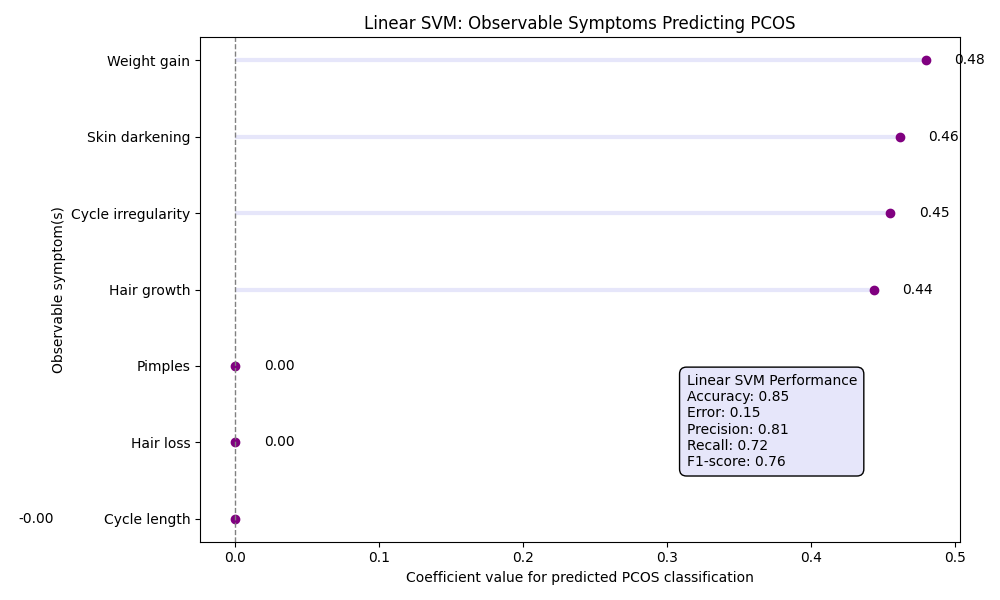

In [42]:
svm_result = run_medical_svm()
svm_result

display(Image(filename="results/medical_svm.png"))

## Random Forest Model

This section displays Random Forest model results and feature importance for observable PCOS symptoms.


Random Forest Model Performance:
Accuracy: 0.83
Error: 0.17
Precision: 0.78
Recall: 0.69
F1-score: 0.74

Random Forest Feature Importance:
              Symptom  Importance
5           Hair loss    0.068727
0  Cycle irregularity    0.091298
6             Pimples    0.092240
2         Weight gain    0.149137
3         Hair growth    0.167287
4      Skin darkening    0.190509
1        Cycle length    0.240802


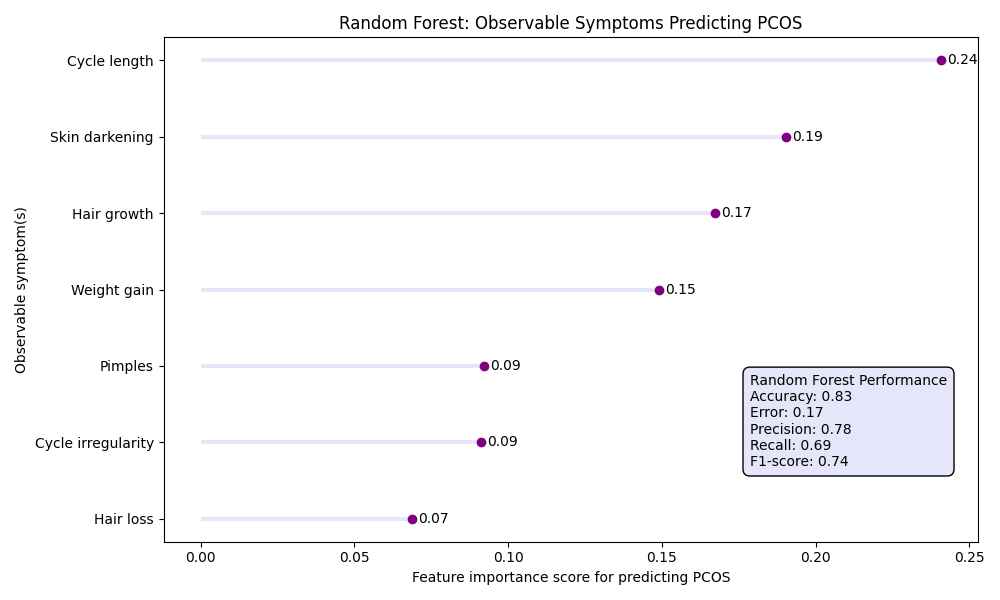

In [43]:
rf_result = run_medical_random_forest()
rf_result

display(Image(filename="results/medical_random_forest_lollipop.png"))

## XGBoost Model

The full project pipeline runs XGBoost through `python src/main.py`. This notebook displays the saved XGBoost chart from the `src/results/` folder. ()

Note: I could not import medical_xgb.py in the notebook, because that automatically imports XGBoost and causes the libomp.dylib error.

In [44]:
from pathlib import Path
from IPython.display import Image, display

xgb_images = list(Path(".").rglob("*xgb*.png")) + list(Path(".").rglob("*xgboost*.png"))

if xgb_images:
    print("Found chart here:")
    print(xgb_images[0])
    display(Image(filename=str(xgb_images[0])))
else:
    print("No XGBoost chart found.")

No XGBoost chart found.


## Lifestyle Behavior Analysis

This section analyzes lifestyle behavior factors, including stress, exercise frequency, sweets intake, and fried food intake.


Raw encoded lifestyle values preview:
  PCOS_Status  Stress_Level  Exercise_Frequency  Diet_Sweets  Diet_Fried_Food
0     No PCOS             0                 1.0            3                3
1     No PCOS             0                 4.0            0                1
2     No PCOS             1                 1.0            1                3
3     No PCOS             1                 0.0            5                5
4     No PCOS             1                 4.0            2                3

Average normalized lifestyle scores by PCOS diagnosis:
PCOS_Status    Lifestyle Factor   No PCOS      PCOS
0                  Stress level  0.597015  0.868421
1            Exercise frequency  0.317010  0.294643
2                 Sweets intake  0.495736  0.593985
3             Fried food intake  0.438166  0.511278


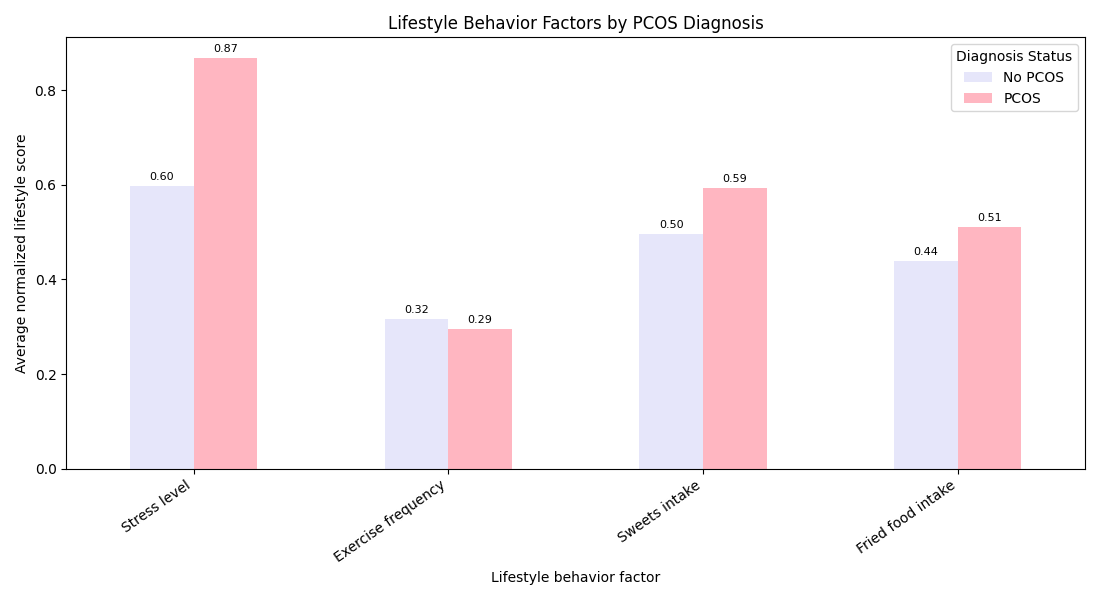

In [45]:
lifestyle_result = run_lifestyle_analysis()
lifestyle_result

display(Image(filename="results/lifestyle_behavior_factors.png"))